<a href="https://colab.research.google.com/github/Phalguni-dhabale/PR-LAB/blob/main/pr_p8_d3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

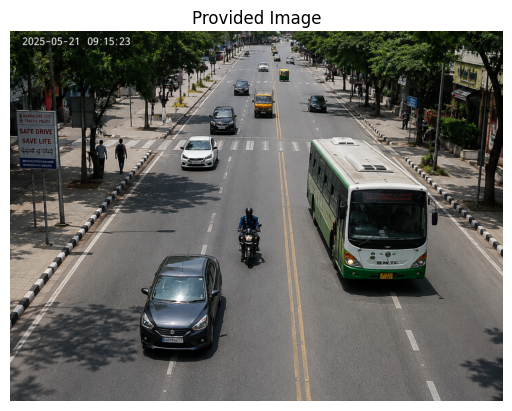

In [2]:
image_path = '/content/ChatGPT Image Aug 10, 2026, 03_05_29 PM.png'

try:
    img = Image.open(image_path)
    plt.imshow(img)
    plt.title('Provided Image')
    plt.axis('off')
    plt.show()
except FileNotFoundError:
    print(f"Error: The file '{image_path}' was not found.")
except Exception as e:
    print(f"An error occurred while loading or displaying the image: {e}")

In [3]:
import pandas as pd

mnist_train_df = pd.read_csv('/content/sample_data/mnist_train_small.csv')
print("Shape of MNIST training dataset:", mnist_train_df.shape)
display(mnist_train_df.head())

Shape of MNIST training dataset: (19999, 785)


,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


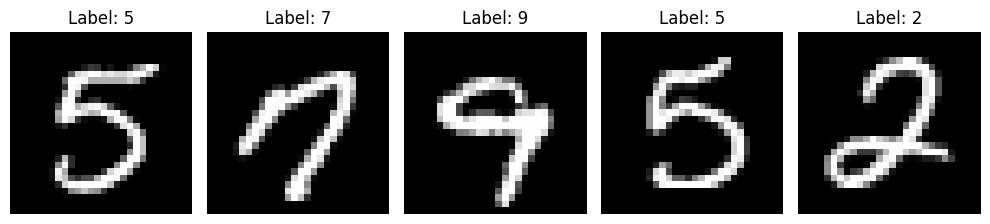

In [4]:

labels = mnist_train_df.iloc[:, 0]
pixels = mnist_train_df.iloc[:, 1:]

plt.figure(figsize=(10, 5))
for i in range(5):

    image_data = pixels.iloc[i].values.reshape(28, 28)
    plt.subplot(1, 5, i + 1)
    plt.imshow(image_data, cmap='gray')
    plt.title(f"Label: {labels.iloc[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X = pixels.values
y = labels.values


X = X / 255.0
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (15999, 784)
y_train shape: (15999,)
X_test shape: (4000, 784)
y_test shape: (4000,)


In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


model = keras.Sequential([
    keras.Input(shape=(784,)),
    layers.Dense(128, activation='relu', name='hidden_layer_1'),
    layers.Dense(128, activation='relu', name='hidden_layer_2'),
    layers.Dense(10, activation='softmax', name='output_layer')
])


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
print("Training the model...")
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("Model training complete.")

Training the model...
Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8779 - loss: 0.4287 - val_accuracy: 0.9356 - val_loss: 0.2434
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9452 - loss: 0.1830 - val_accuracy: 0.9459 - val_loss: 0.1912
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9648 - loss: 0.1196 - val_accuracy: 0.9434 - val_loss: 0.1901
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9726 - loss: 0.0895 - val_accuracy: 0.9516 - val_loss: 0.1788
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9821 - loss: 0.0649 - val_accuracy: 0.9606 - val_loss: 0.1560
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9855 - loss: 0.0485 - val_accuracy: 0.9581 - val_loss: 0.1740
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9899 - loss: 0.0334 - val_accuracy: 0.9541 - val_loss: 0.1872
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9921 - loss: 0.0

Evaluating the model on the test data...
Test Loss: 0.1550
Test Accuracy: 0.9640


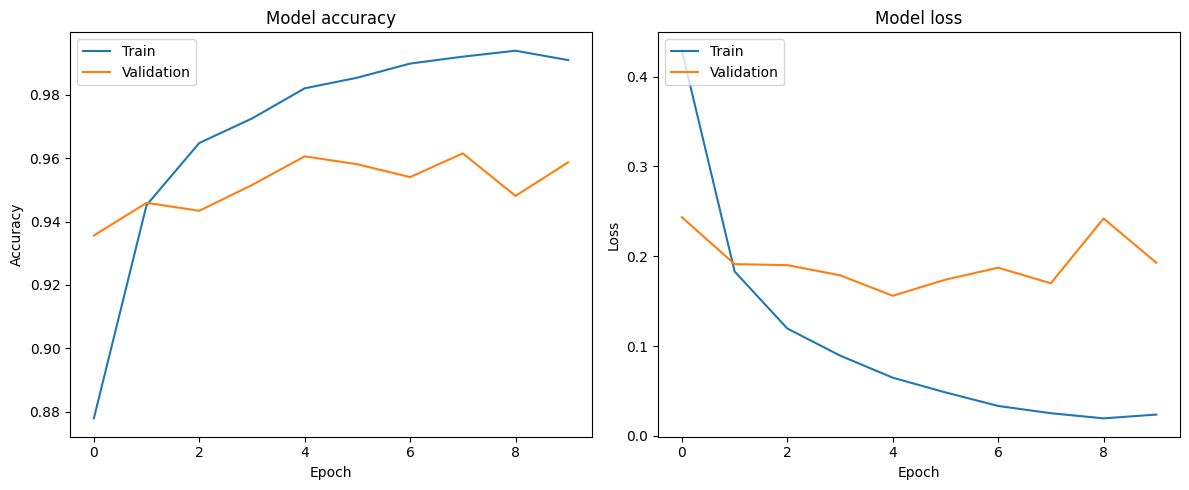

In [8]:

print("Evaluating the model on the test data...")
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()